Projet : multi-classification avec target = gravité

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_evenements = pd.read_csv(r"C:\Users\Utilisateur\Documents\2026-03-17_projet_final_certification_devIA\data\evenements.csv")

In [3]:
df_evenements.gravite.value_counts()

gravite
significatif    37
grave           17
mineur           6
Name: count, dtype: int64

In [4]:
df_evenements

,id_evenement,date,annee,type_evenement,gravite,departement,exploitant,nb_morts,nb_blesses,cause_presumee,contexte,source
0,1,2010-02-11,2010,collision,grave,59,SNCF Réseau,1,7,erreur_humaine,circulation_commerciale,EPSF_synthese
1,2,2010-05-03,2010,incident_materiel,significatif,69,SNCF Voyageurs,0,2,defaillance_materiel,circulation_commerciale,SNCF_rapport
2,3,2010-09-18,2010,PN,grave,33,SNCF Réseau,2,1,obstacle_PN,PN,BEATT_rapport
3,4,2011-01-24,2011,deraillement,significatif,13,SNCF Réseau,0,3,defaut_infrastructure,travaux,EPSF_synthese
4,5,2011-04-09,2011,acte_malveillance,significatif,75,SNCF Réseau,0,0,acte_malveillance,circulation_commerciale,SNCF_rapport
5,6,2011-07-21,2011,incident_materiel,mineur,67,SNCF Voyageurs,0,1,defaillance_materiel,circulation_commerciale,SNCF_rapport
6,7,2011-11-30,2011,incendie,grave,93,SNCF Voyageurs,0,5,incendie_bord,maintenance,EPSF_synthese
7,8,2012-02-15,2012,PN,significatif,62,SNCF Réseau,0,2,non_respect_signalisation,PN,EPSF_synthese
8,9,2012-03-28,2012,collision,grave,31,SNCF Réseau,1,4,erreur_humaine,circulation_commerciale,BEATT_rapport
9,10,2012-06-10,2012,incident_materiel,mineur,44,SNCF Voyageurs,0,0,defaillance_freinage,essais,SNCF_rapport


In [5]:
# Aperçu
print(df_evenements.head())

# Colonnes
print(df_evenements.columns)

# Infos générales
print(df_evenements.info())

   id_evenement        date  annee     type_evenement       gravite  \
0             1  2010-02-11   2010          collision         grave   
1             2  2010-05-03   2010  incident_materiel  significatif   
2             3  2010-09-18   2010                 PN         grave   
3             4  2011-01-24   2011       deraillement  significatif   
4             5  2011-04-09   2011  acte_malveillance  significatif   

   departement      exploitant  nb_morts  nb_blesses         cause_presumee  \
0           59     SNCF Réseau         1           7         erreur_humaine   
1           69  SNCF Voyageurs         0           2   defaillance_materiel   
2           33     SNCF Réseau         2           1            obstacle_PN   
3           13     SNCF Réseau         0           3  defaut_infrastructure   
4           75     SNCF Réseau         0           0      acte_malveillance   

                  contexte         source  
0  circulation_commerciale  EPSF_synthese  
1  circula

In [6]:
print(df_evenements.columns)

Index(['id_evenement', 'date', 'annee', 'type_evenement', 'gravite',
       'departement', 'exploitant', 'nb_morts', 'nb_blesses', 'cause_presumee',
       'contexte', 'source'],
      dtype='object')


In [7]:
df_evenements = df_evenements.drop(columns=["id_evenement", "nb_morts", "nb_blesses", "date"], errors="ignore")
X = df_evenements.drop(columns=["gravite"])
y = df_evenements["gravite"]
df_evenements

,annee,type_evenement,gravite,departement,exploitant,cause_presumee,contexte,source
0,2010,collision,grave,59,SNCF Réseau,erreur_humaine,circulation_commerciale,EPSF_synthese
1,2010,incident_materiel,significatif,69,SNCF Voyageurs,defaillance_materiel,circulation_commerciale,SNCF_rapport
2,2010,PN,grave,33,SNCF Réseau,obstacle_PN,PN,BEATT_rapport
3,2011,deraillement,significatif,13,SNCF Réseau,defaut_infrastructure,travaux,EPSF_synthese
4,2011,acte_malveillance,significatif,75,SNCF Réseau,acte_malveillance,circulation_commerciale,SNCF_rapport
5,2011,incident_materiel,mineur,67,SNCF Voyageurs,defaillance_materiel,circulation_commerciale,SNCF_rapport
6,2011,incendie,grave,93,SNCF Voyageurs,incendie_bord,maintenance,EPSF_synthese
7,2012,PN,significatif,62,SNCF Réseau,non_respect_signalisation,PN,EPSF_synthese
8,2012,collision,grave,31,SNCF Réseau,erreur_humaine,circulation_commerciale,BEATT_rapport
9,2012,incident_materiel,mineur,44,SNCF Voyageurs,defaillance_freinage,essais,SNCF_rapport


In [8]:
mapping_gravite = {"mineur": 0, "significatif": 1, "grave": 2}
y = y.map(mapping_gravite)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

In [10]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Colonnes catégorielles :", cat_cols)
print("Colonnes numériques :", num_cols)

Colonnes catégorielles : ['type_evenement', 'exploitant', 'cause_presumee', 'contexte', 'source']
Colonnes numériques : ['annee', 'departement']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

In [12]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

In [13]:
model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", rf_clf),
    ]
)

In [14]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type_evenement',
                                                   'exploitant',
                                                   'cause_presumee', 'contexte',
                                                   'source']),
                                                 ('num', 'passthrough',
                                                  ['annee', 'departement'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("\nClassification report :")
print(classification_report(y_test, y_pred))
print("\nMatrice de confusion :")
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print(cm)


Classification report :
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.85      0.89      0.87        19
           2       0.88      0.88      0.88         8

    accuracy                           0.83        30
   macro avg       0.74      0.70      0.72        30
weighted avg       0.82      0.83      0.83        30


Matrice de confusion :
[[ 1  2  0]
 [ 1 17  1]
 [ 0  1  7]]


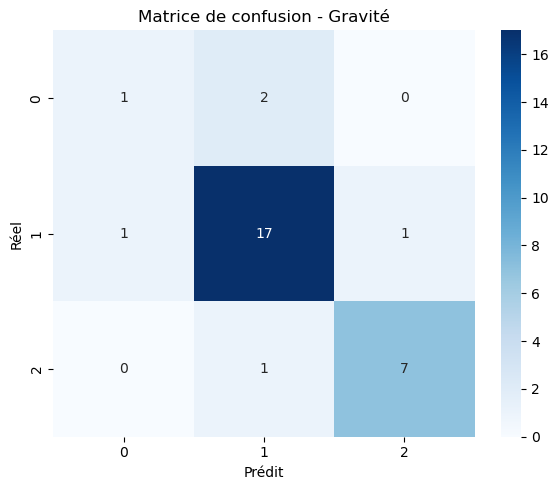

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Gravité")
plt.tight_layout()
plt.show()

In [18]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = list(cat_feature_names) + num_cols

importances = model.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("\nTop 20 features les plus importantes :")
print(feat_imp.head(20))


Top 20 features les plus importantes :
annee                                       0.176159
source_SNCF_rapport                         0.103348
departement                                 0.099659
source_BEATT_rapport                        0.085790
type_evenement_incident_materiel            0.073374
cause_presumee_defaillance_freinage         0.062024
contexte_essais                             0.052932
source_EPSF_synthese                        0.049907
exploitant_SNCF Réseau                      0.044185
exploitant_SNCF Voyageurs                   0.042296
contexte_PN                                 0.023451
cause_presumee_erreur_humaine               0.021129
cause_presumee_defaillance_materiel         0.020392
contexte_circulation_commerciale            0.019260
type_evenement_incendie                     0.014328
cause_presumee_incendie_bord                0.014299
type_evenement_PN                           0.014231
type_evenement_deraillement                 0.012911
cause_

In [19]:
import mlflow
import xgboost as xgb

In [20]:
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

In [21]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [22]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [23]:
grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

Meilleurs hyperparamètres trouvés :
{'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 10, 'clf__n_estimators': 200}


In [24]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [25]:
print("\nClassification report :")
print(classification_report(y_test, y_pred))


Classification report :
              precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.88      0.74      0.80        19
           2       0.78      0.88      0.82         8

    accuracy                           0.77        30
   macro avg       0.68      0.76      0.71        30
weighted avg       0.80      0.77      0.78        30




Matrice de confusion :
[[ 2  1  0]
 [ 3 14  2]
 [ 0  1  7]]


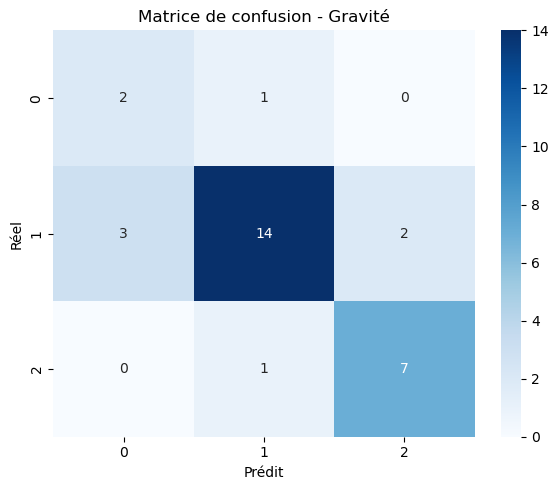

In [26]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print("\nMatrice de confusion :")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Gravité")
plt.tight_layout()
plt.show()

In [27]:
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = list(cat_feature_names) + num_cols

importances = best_model.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("\nTop 20 features les plus importantes :")
print(feat_imp.head(20))


Top 20 features les plus importantes :
source_SNCF_rapport                     0.163693
type_evenement_incident_materiel        0.118852
annee                                   0.117728
source_BEATT_rapport                    0.103464
cause_presumee_defaillance_freinage     0.066925
exploitant_SNCF Voyageurs               0.058521
departement                             0.058073
contexte_essais                         0.054718
exploitant_SNCF Réseau                  0.047114
contexte_PN                             0.031718
source_EPSF_synthese                    0.023803
type_evenement_PN                       0.021315
cause_presumee_erreur_humaine           0.019891
contexte_circulation_commerciale        0.017448
cause_presumee_defaillance_materiel     0.016764
type_evenement_collision                0.009772
cause_presumee_obstacle_PN              0.009631
type_evenement_acte_malveillance        0.008882
type_evenement_deraillement             0.008536
cause_presumee_defaut_infrast

In [28]:
df_evenements_1500 = pd.read_csv(r"C:\Users\Utilisateur\Documents\2026-03-17_projet_final_certification_devIA\data\evenements_1500.csv")
df_evenements_1500

,id_evenement,date,annee,type_evenement,gravite,departement,exploitant,nb_morts,nb_blesses,cause_presumee,contexte,source
0,1,2024-05-05,2024,collision,significatif,44,SNCF Réseau,1,7,erreur_humaine,circulation_commerciale,EPSF_synthese
1,2,2012-04-19,2012,incendie,significatif,72,RATP,0,2,acte_malveillance,circulation_commerciale,EPSF_synthese
2,3,2010-09-02,2010,collision,mineur,87,SNCF Voyageurs,0,0,non_respect_signalisation,circulation_commerciale,EPSF_synthese
3,4,2022-08-03,2022,incident_materiel,mineur,86,SNCF Voyageurs,0,0,defaut_infrastructure,circulation_commerciale,SNCF_rapport
4,5,2010-02-23,2010,incident_materiel,significatif,34,SNCF Voyageurs,0,7,defaut_infrastructure,maintenance,EPSF_synthese
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,2017-07-08,2017,collision,significatif,91,SNCF Voyageurs,0,7,defaillance_signalisation,circulation_commerciale,BEATT_rapport
1496,1497,2015-03-20,2015,acte_malveillance,significatif,13,SNCF Réseau,0,8,jet_de_projectiles,circulation_commerciale,BEATT_rapport
1497,1498,2012-10-13,2012,PN,significatif,89,SNCF Réseau,0,5,obstacle_PN,PN,EPSF_synthese
1498,1499,2011-05-06,2011,incident_materiel,mineur,38,SNCF Voyageurs,0,0,defaillance_signalisation,maintenance,EPSF_synthese


In [29]:
df_evenements_all = pd.concat(
    [df_evenements, df_evenements_1500],
    ignore_index=True
)
df_evenements_all

,annee,type_evenement,gravite,departement,exploitant,cause_presumee,contexte,source,id_evenement,date,nb_morts,nb_blesses
0,2010,collision,grave,59,SNCF Réseau,erreur_humaine,circulation_commerciale,EPSF_synthese,NaN,NaN,NaN,NaN
1,2010,incident_materiel,significatif,69,SNCF Voyageurs,defaillance_materiel,circulation_commerciale,SNCF_rapport,NaN,NaN,NaN,NaN
2,2010,PN,grave,33,SNCF Réseau,obstacle_PN,PN,BEATT_rapport,NaN,NaN,NaN,NaN
3,2011,deraillement,significatif,13,SNCF Réseau,defaut_infrastructure,travaux,EPSF_synthese,NaN,NaN,NaN,NaN
4,2011,acte_malveillance,significatif,75,SNCF Réseau,acte_malveillance,circulation_commerciale,SNCF_rapport,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1555,2017,collision,significatif,91,SNCF Voyageurs,defaillance_signalisation,circulation_commerciale,BEATT_rapport,1496.0,2017-07-08,0.0,7.0
1556,2015,acte_malveillance,significatif,13,SNCF Réseau,jet_de_projectiles,circulation_commerciale,BEATT_rapport,1497.0,2015-03-20,0.0,8.0
1557,2012,PN,significatif,89,SNCF Réseau,obstacle_PN,PN,EPSF_synthese,1498.0,2012-10-13,0.0,5.0
1558,2011,incident_materiel,mineur,38,SNCF Voyageurs,defaillance_signalisation,maintenance,EPSF_synthese,1499.0,2011-05-06,0.0,0.0


Meilleurs hyperparamètres trouvés :
{'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}

Classification report :
              precision    recall  f1-score   support

       grave       0.52      0.55      0.53       266
      mineur       0.45      0.58      0.51       203
significatif       0.45      0.34      0.39       311

    accuracy                           0.47       780
   macro avg       0.47      0.49      0.48       780
weighted avg       0.47      0.47      0.47       780


Matrice de confusion :
[[147  48  71]
 [ 28 118  57]
 [109  97 105]]


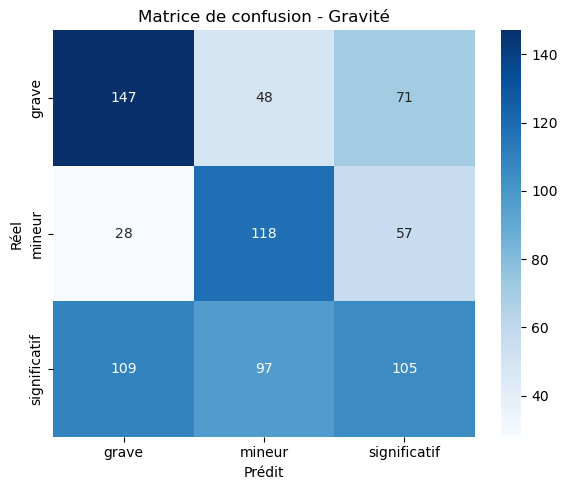


Top 20 features les plus importantes :
type_evenement_incident_materiel            0.126438
departement                                 0.108347
exploitant_SNCF Réseau                      0.098597
annee                                       0.091867
type_evenement_PN                           0.062848
exploitant_RATP                             0.051787
type_evenement_acte_malveillance            0.042419
cause_presumee_defaillance_freinage         0.034808
type_evenement_collision                    0.034446
cause_presumee_non_respect_signalisation    0.026251
cause_presumee_vol_cable                    0.026131
source_EPSF_synthese                        0.024723
source_BEATT_rapport                        0.023991
exploitant_SNCF Voyageurs                   0.023889
contexte_PN                                 0.021419
contexte_circulation_commerciale            0.021161
source_SNCF_rapport                         0.018585
contexte_maintenance                        0.018188
cause_

In [30]:
# 2. Suppression des colonnes non utilisables comme features
df_evenements_all = df_evenements_all.drop(columns=["id_evenement", "nb_morts", "nb_blesses", "date"])

# 3. Définition des features et de la target
X = df_evenements_all.drop(columns=["gravite"])
y = df_evenements_all["gravite"]

# 4. Split train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

# 5. Colonnes catégorielles et numériques
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# 6. Préprocesseur (One-Hot Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# 7. Modèle de base
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# 8. Pipeline
pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", rf),
    ]
)

# 9. Grille d'hyperparamètres
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

# 10. Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 11. GridSearchCV
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

# 12. Entraînement
grid.fit(X_train, y_train)

print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

# 13. Prédictions avec le meilleur modèle
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# 14. Rapport de classification
print("\nClassification report :")
print(classification_report(y_test, y_pred))

# 15. Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
print("\nMatrice de confusion :")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Gravité")
plt.tight_layout()
plt.show()

# 16. Importance des features
ohe = best_model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feature_names = list(cat_feature_names) + num_cols

importances = best_model.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("\nTop 20 features les plus importantes :")
print(feat_imp.head(20))

In [31]:
import joblib

# Sauvegarde du pipeline complet (préprocessing + modèle)
# On sauvegarde le best_model issu du GridSearchCV
joblib.dump(best_model, "../models/rf_gravite_pipeline.joblib")

# Pour vérifier que tout fonctionne, on le recharge et on teste
model_charge = joblib.load("../models/rf_gravite_pipeline.joblib")
print("Vérification :", model_charge.predict(X_test[:3]))

Vérification : ['significatif' 'significatif' 'grave']
